# QAOA for Portfolio Selection

Choosing exactly `B` assets from `n` to maximise return minus risk — and the two
ways of handling that "exactly `B`" constraint.

Companion to [`tutorials/02-optimization/02-qaoa-portfolio-selection.md`](../tutorials/02-optimization/02-qaoa-portfolio-selection.md).

**Requires:** `pip install -e ".[qiskit]"`

> New to QAOA? Start with [`04-qaoa-maxcut.ipynb`](04-qaoa-maxcut.ipynb) — Max-Cut
> is unconstrained, which isolates one variable.

## 1. Problem → QUBO

An Ising Hamiltonian has no notion of "subject to", so the cardinality constraint
has to be folded into the objective as a penalty:

```
maximise   mu^T x - lambda * x^T Sigma x     subject to sum(x) = B
minimise  -mu^T x + lambda * x^T Sigma x + P * (sum(x) - B)^2
```

In [1]:
from qprac_lab.algorithms.optimization.qubo_builder import portfolio_qubo
from qprac_lab.data.synthetic import make_small_portfolio_dataset

returns, covariance = make_small_portfolio_dataset(n_assets=6)
qubo = portfolio_qubo(returns, covariance, budget=3, risk_lambda=0.5)

print(f"assets:  {qubo.num_variables}")
print(f"penalty: {qubo.metadata['penalty']:.3f}")
print(f"QUBO optimum: {qubo.brute_force()['selection']}  (feasible: sums to 3)")

assets:  6
penalty: 6.170
QUBO optimum: [1 0 1 1 0 0]  (feasible: sums to 3)


## 2. QUBO → Ising

Substitute `x = (1 - z)/2`, where `z` is the ±1 eigenvalue of a Pauli-Z. A
classical cost function must map to a **diagonal** Hamiltonian — if yours has `X`
or `Y` terms, the mapping is wrong.

In [2]:
cost_operator, offset = qubo.to_ising()
print(f"qubits: {cost_operator.num_qubits}, terms: {len(cost_operator)}")
print(f"all diagonal (I/Z only): {all(set(p) <= {'I','Z'} for p in cost_operator.paulis.to_labels())}")

qubits: 6, terms: 21
all diagonal (I/Z only): True


The mapping is verified exhaustively in the test suite — every one of the `2^n`
assignments must give the same energy under the QUBO and the Ising operator.
Here is that check on a handful of them.

In [3]:
import numpy as np
from qiskit.quantum_info import Statevector

worst = 0.0
for index in range(2 ** qubo.num_variables):
    x = np.array([(index >> b) & 1 for b in range(qubo.num_variables)])
    label = "".join(str(b) for b in reversed(x))          # Qiskit is little-endian
    ising = float(Statevector.from_label(label).expectation_value(cost_operator).real) + offset
    worst = max(worst, abs(ising - qubo.objective(x)))
print(f"max |ising - qubo| over all {2**qubo.num_variables} assignments: {worst:.2e}")

max |ising - qubo| over all 64 assignments: 1.78e-14


## 3. Penalty encoding, and why it disappoints

There are 20 feasible portfolios, so **random guessing among feasible states hits
the optimum 5% of the time.** That is the bar `optimal_probability_lift` measures
against — and it is reported by default so the result cannot be oversold.

In [4]:
from qprac_lab.algorithms.optimization.qaoa_portfolio_selection import (
    run_qaoa_portfolio_selection_tutorial,
)

penalty_run = run_qaoa_portfolio_selection_tutorial(reps=3)

print(f"selected assets:     {penalty_run.selected_assets}")
print(f"objective:           {penalty_run.objective_value:+.6f}")
print(f"matches brute force: {penalty_run.matches_brute_force}")
print()
print(f"feasible samples:    {penalty_run.feasible_probability:.1%}")
print(f"hits the optimum:    {penalty_run.optimal_probability:.2%}")
print(f"random guessing:     {penalty_run.uniform_feasible_probability:.2%}")
print(f"lift:                {penalty_run.optimal_probability_lift:.2f}x   <- barely above 1.0")

selected assets:     [0, 2, 3]
objective:           +0.333631
matches brute force: True

feasible samples:    94.7%
hits the optimum:    5.27%
random guessing:     5.00%
lift:                1.05x   <- barely above 1.0


The penalty (6.17) dwarfs the entire spread of objective values across feasible
portfolios (~2.1). QAOA spends its angles learning feasibility and has little
left for optimality.

Lowering the penalty sharpens the distribution — and breaks feasibility. One
failure traded for another.

In [5]:
weak = run_qaoa_portfolio_selection_tutorial(reps=6, penalty=0.5)
print(f"penalty=0.5:  feasible {weak.feasible_probability:.1%}, "
      f"lift {weak.optimal_probability_lift:.2f}x")

penalty=0.5:  feasible 54.8%, lift 1.98x


## 4. The XY mixer removes the tradeoff

`(X_i X_j + Y_i Y_j)/2` commutes with the total number operator, so evolution
under it **cannot change Hamming weight**. Start in a 3-hot state and the
optimisation cannot leave the feasible subspace. The penalty term is dropped
entirely and every angle works on the objective.

In [6]:
xy = run_qaoa_portfolio_selection_tutorial(mixer="xy", reps=6)

print(f"mixer:            {xy.mixer}")
print(f"penalty:          {xy.problem['penalty']}  <- no penalty term at all")
print(f"feasible samples: {xy.feasible_probability:.1%}   <- exact, by construction")
print(f"hits the optimum: {xy.optimal_probability:.2%}")
print(f"lift:             {xy.optimal_probability_lift:.2f}x")

mixer:            xy:ring
penalty:          0.0  <- no penalty term at all
feasible samples: 100.0%   <- exact, by construction
hits the optimum: 100.00%
lift:             20.00x


Two honest caveats on that result.

**It is not monotonic in depth.** All depths use the same fixed linear-ramp warm
start, and COBYLA settles into different local optima from it. `p = 6` is not
special — it is where this particular warm start happens to land well.

In [7]:
print(f"{'p':>3} {'feasible':>10} {'optimum':>9} {'lift':>7}")
for reps in (3, 4, 6, 8):
    run = run_qaoa_portfolio_selection_tutorial(mixer="xy", reps=reps, shots=2048)
    print(f"{reps:>3} {run.feasible_probability:>9.1%} {run.optimal_probability:>8.2%} "
          f"{run.optimal_probability_lift:>6.2f}x")

  p   feasible   optimum    lift


  3    100.0%    3.42%   0.68x


  4    100.0%    4.98%   1.00x


  6    100.0%  100.00%  20.00x


  8    100.0%   17.09%   3.42x


**And the guarantee does not survive noise.** 100% feasibility is a property of
the *ideal unitary*; depolarizing and readout errors move amplitude straight out
of the fixed-weight subspace.

In [8]:
print(f"{'noise':>10} {'feasible':>10} {'lift':>7}")
for noise in [None, "light", "moderate"]:
    run = run_qaoa_portfolio_selection_tutorial(
        mixer="xy", reps=6, backend="aer", noise=noise, shots=2048, maxiter=150,
    )
    print(f"{noise or 'ideal':>10} {run.feasible_probability:>9.1%} "
          f"{run.optimal_probability_lift:>6.2f}x")

     noise   feasible    lift


     ideal    100.0%  19.94x


     light     82.7%  15.74x


  moderate     46.2%   5.77x


So: the XY mixer is clearly the better construction, but on hardware you still
need the feasibility filter the penalty encoding required. It changes *what* you
must check, not *whether*.

## 5. Classical baselines

In [9]:
for name, payload in xy.baseline_report.items():
    print(f"{name:>22}: {payload['selection']}  objective {payload['objective_value']:+.6f}")

           brute_force: [1, 0, 1, 1, 0, 0]  objective +0.333631
                greedy: [1, 0, 1, 0, 0, 1]  objective -0.305651
   simulated_annealing: [1, 0, 1, 1, 0, 0]  objective +0.333631


Greedy fails instructively — ranking by return alone ignores covariance, so it
happily picks three correlated assets. Simulated annealing matches the exact
optimum in milliseconds, which is the real bar any quantum claim has to clear.

## 6. What QAOA actually sampled

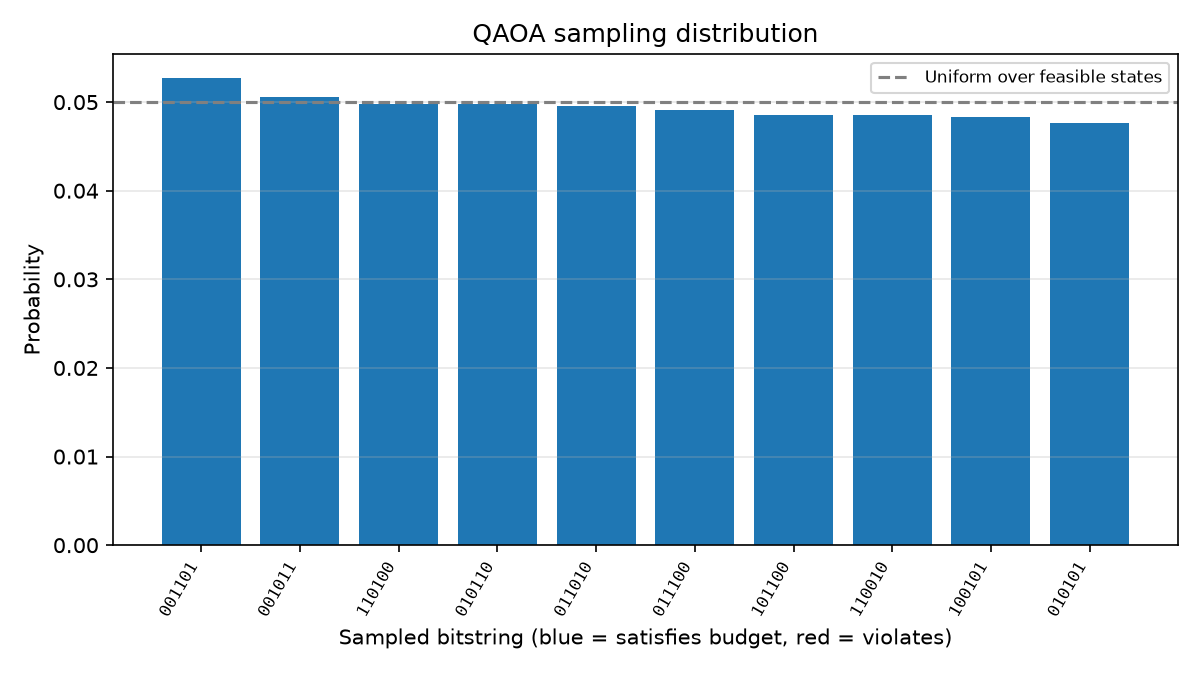

In [10]:
from qprac_lab.visualization.tutorial_outputs import plot_qaoa_distribution
from IPython.display import Image

Image(plot_qaoa_distribution(
    penalty_run.top_bitstrings,
    output_path="../results/nb_qaoa_distribution.png",
    uniform_feasible_probability=penalty_run.uniform_feasible_probability,
))

Every bar sits on the uniform line — that is the 1.05x lift, drawn.

## When not to use this

- **When brute force fits.** At `n = 6` exhaustive search is exact and instant.
- **When simulated annealing already ties**, as it does here.
- **On noisy hardware without a feasibility filter.**
- **At shallow depth**, where a strongly-penalised landscape is near-uniform.